- Grid search
- Randomized grid search
- Halving grid search


In [1]:
import pandas as pd

In [2]:
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/pima.csv'
data = pd.read_csv(url)

In [3]:
data.head(5)

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# feature matrix X, target vector u

y = data.label
X = data.drop('label', axis=1)

In [5]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y)

In [6]:
# knn model
from sklearn.neighbors import KNeighborsClassifier
knn_clf = KNeighborsClassifier()

In [7]:
# import the grid search function

In [8]:
from sklearn.model_selection import GridSearchCV # CV = cross-validation

# define a parameter dictionary
param_dic = {'n_neighbors':list(range(1,50))}


In [9]:
grid = GridSearchCV(knn_clf,
                   param_dic,
                   scoring='accuracy', # evaluation metric: accuracy, recall, precision, etc
                   cv = 10, # number of folds in cross validation
                    n_jobs = -1, # optional: use all CPUs
                    verbose = 1 # the higher, the more messages
                   ) 

In [10]:
grid.fit(X_train, y_train)

Fitting 10 folds for each of 49 candidates, totalling 490 fits


GridSearchCV(cv=10, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30, ...]},
             scoring='accuracy', verbose=1)

In [11]:
# grid search results

In [12]:
results = pd.DataFrame(grid.cv_results_)

<AxesSubplot:>

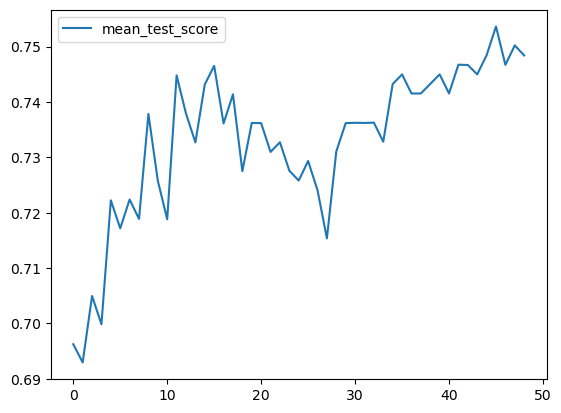

In [13]:
results[['mean_test_score','params']].plot()

In [14]:
# best hyperparameters
grid.best_params_

{'n_neighbors': 46}

In [15]:
# best classifier
best_clf = grid.best_estimator_

grid.best_score_ # accuracy of best classifier

0.7536297640653358

In [16]:
# test your best classifier
y_test_pred = best_clf.predict(X_test)
from sklearn.metrics import accuracy_score

In [17]:
accuracy_score(y_test,y_test_pred)

0.7239583333333334

## Searching over multiple hyperparameters

knn has a 'weights' parameter

- uniform (weights)
- distance (weight points by the inverse of the distance


In [18]:
param_dic = {'n_neighbors': list(range(1,50)),
            'weights':['uniform', 'distance']}

In [19]:
grid = GridSearchCV(knn_clf,
                   param_dic,
                   scoring='accuracy', # evaluation metric: accuracy, recall, precision, etc
                   cv = 10, # number of folds in cross validation
                    n_jobs = -1, # optional: use all CPUs
                    verbose = 1 # the higher, the more messages
                   ) 

In [20]:
grid.fit(X_train, y_train)

Fitting 10 folds for each of 98 candidates, totalling 980 fits


GridSearchCV(cv=10, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30, ...],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=1)

In [21]:
grid.best_params_

{'n_neighbors': 46, 'weights': 'uniform'}

In [22]:
best_clf = grid.best_estimator_

In [23]:
# test your best classifier
y_test_pred = best_clf.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_test_pred)

0.7239583333333334

## Randomized Grid Search

In [24]:
from sklearn.model_selection import RandomizedSearchCV

In [25]:
grid = RandomizedSearchCV(knn_clf,
                        param_dic,
                        scoring='accuracy',
                        cv=10,
                        n_jobs=-1,
                        n_iter=20 # number of random sample parameter combinations
                        )

In [26]:
grid.fit(X_train,y_train)

RandomizedSearchCV(cv=10, estimator=KNeighborsClassifier(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8,
                                                        9, 10, 11, 12, 13, 14,
                                                        15, 16, 17, 18, 19, 20,
                                                        21, 22, 23, 24, 25, 26,
                                                        27, 28, 29, 30, ...],
                                        'weights': ['uniform', 'distance']},
                   scoring='accuracy')

In [27]:
results = pd.DataFrame(grid.cv_results_)
results[['mean_test_score', 'params']]

,mean_test_score,params
0,0.696249,"{'weights': 'distance', 'n_neighbors': 1}"
1,0.696249,"{'weights': 'uniform', 'n_neighbors': 1}"
2,0.718875,"{'weights': 'uniform', 'n_neighbors': 8}"
3,0.744949,"{'weights': 'distance', 'n_neighbors': 42}"
4,0.741470,"{'weights': 'distance', 'n_neighbors': 47}"
5,0.741440,"{'weights': 'distance', 'n_neighbors': 35}"
6,0.710254,"{'weights': 'distance', 'n_neighbors': 7}"
7,0.739625,"{'weights': 'distance', 'n_neighbors': 15}"
8,0.715366,"{'weights': 'uniform', 'n_neighbors': 28}"
9,0.744979,"{'weights': 'uniform', 'n_neighbors': 44}"


In [28]:
grid.best_params_

{'weights': 'distance', 'n_neighbors': 46}

In [29]:
grid.best_score_

0.74670296430732

In [30]:
best_clf = grid.best_estimator_

In [31]:
# test... it the same

## Successive Halving

In [33]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

In [ ]:
grid = HalvingGridSearchCV(knn_clf,
                           param_dic,
                           cv=10,
                           factor = 2, # half of param combinations selected each round
                          scoring = 'accuracy') 

In [ ]:
import numpy as np